<a href="https://www.kaggle.com/code/janmartins/financial-giants-and-revenue?scriptVersionId=224818612" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Bibliotecas usadas para carregamento e manipulação de dados; e geração de gráficos.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/global-financial-giants-by-revenue-2024/largest financial services companies by revenue.csv


In [2]:
# Leitura dos dados e apresentação das primeiras linhas

df = pd.read_csv("/kaggle/input/global-financial-giants-by-revenue-2024/largest financial services companies by revenue.csv")
df.head()

,Rank,Company,Industry,Revenue in (USD Million),Net Income in (USD Millions),Total Assest in (USD Millions),Headquarters
0,1,Transamerica Corporation,Conglomerate,245510,42521,873,United States
1,2,Ping An Insurance Group,Insurance,191509,20738,1460,China
2,3,ICBC,Banking,182794,45783,5110,China
3,4,China Construction Bank,Banking,172000,39282,4311,China
4,5,Agricultural Bank of China,Banking,153884,31293,4169,China


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Rank                            50 non-null     int64 
 1   Company                         50 non-null     object
 2   Industry                        50 non-null     object
 3   Revenue in (USD Million)        50 non-null     int64 
 4   Net Income in (USD Millions)    50 non-null     int64 
 5   Total Assest in (USD Millions)  50 non-null     int64 
 6   Headquarters                    50 non-null     object
dtypes: int64(4), object(3)
memory usage: 2.9+ KB


In [4]:
# Verificando os vamos nulos das colunas
df.isnull().sum()

Rank                              0
Company                           0
Industry                          0
Revenue in (USD Million)          0
Net Income in (USD Millions)      0
Total Assest in (USD Millions)    0
Headquarters                      0
dtype: int64

In [5]:
# Estatísticas sobre as colunas númericas

df.describe()

,Rank,Revenue in (USD Million),Net Income in (USD Millions),Total Assest in (USD Millions)
count,50.00000,50.000000,50.000000,50.00000
mean,25.50000,85435.120000,9369.320000,1480.46000
std,14.57738,44689.154251,11101.187832,1282.83769
min,1.00000,14592.000000,169.000000,13.00000
25%,13.25000,56189.250000,3030.250000,588.00000
50%,25.50000,70736.000000,4963.000000,1024.50000
75%,37.75000,96284.250000,10660.750000,2183.75000
max,50.00000,245510.000000,45783.000000,5110.00000


# Receita por empresa

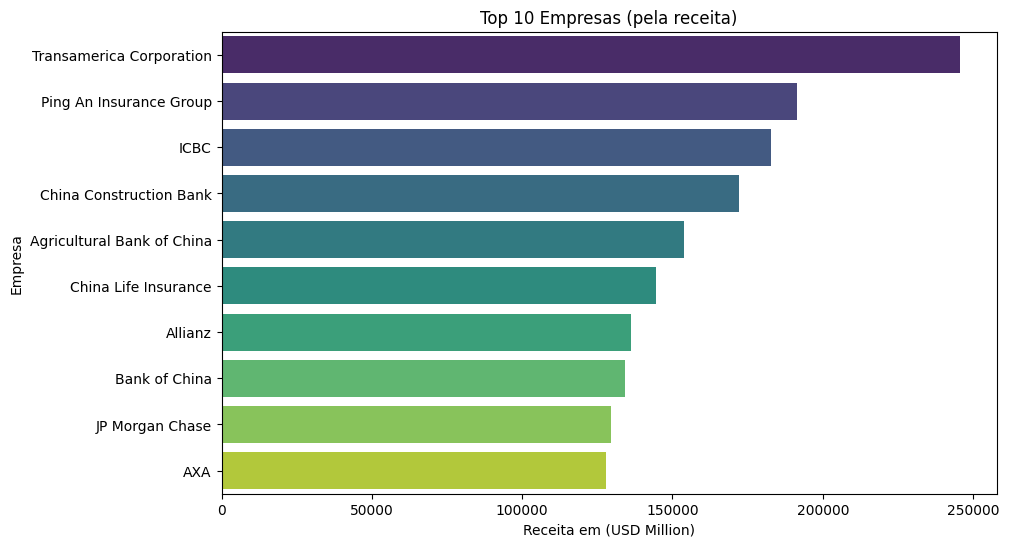

In [6]:
# Selecionamos as 10 empresas com maior classificação e receita em milhões de dólares

top_10 = df[['Rank', 'Company', 'Revenue in (USD Million)']].nlargest(10, 'Revenue in (USD Million)')
plt.figure(figsize=(10, 6))
sns.barplot(x='Revenue in (USD Million)', y='Company', data=top_10, palette='viridis')
plt.title('Top 10 Empresas (pela receita)')
plt.xlabel('Receita em (USD Million)')
plt.ylabel('Empresa')
plt.show()

In [7]:
# Aqui vamos apresentar dados estatísticos sobre as empresas pela indústria na qual fazem parte e sua receita.

df_grouped = df.groupby('Industry')[['Revenue in (USD Million)', 'Net Income in (USD Millions)', 'Total Assest in (USD Millions)']].agg(['mean', 'std', 'min', 'max'])
print(df_grouped)

                    Revenue in (USD Million)                                \
                                        mean           std     min     max   
Industry                                                                     
Banking                         88008.700000  44399.538400   14592  182794   
Conglomerate                   245510.000000           NaN  245510  245510   
Insurance                       81346.565217  36819.106995   46788  191509   
Investment Services             65850.166667  20675.044333   52047  106437   

                    Net Income in (USD Millions)                              \
                                            mean           std    min    max   
Industry                                                                       
Banking                             14624.250000  12984.503808   1882  45783   
Conglomerate                        42521.000000           NaN  42521  42521   
Insurance                            4054.652174   40

# Comparando Receita e Lucro Líquido

In [8]:
# Remover os espaços vazios que temos nas colunas

df.columns = df.columns.str.strip()

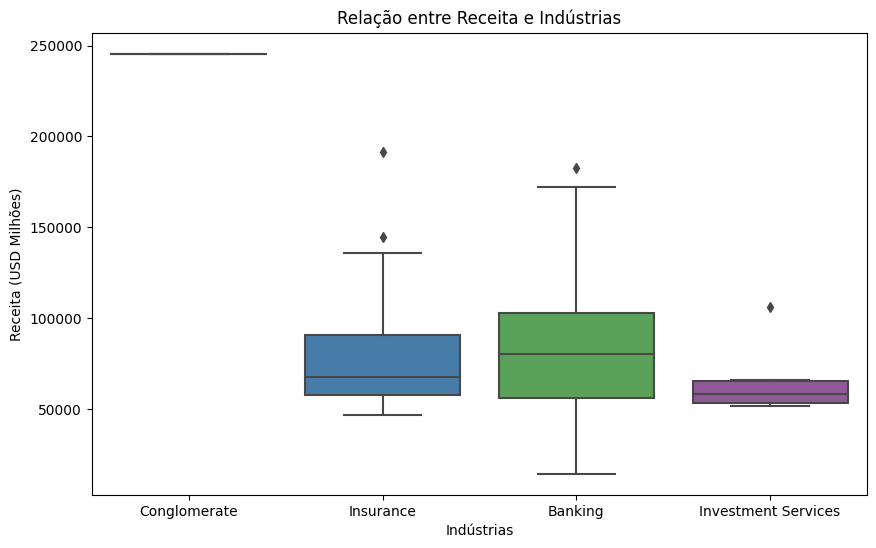

In [9]:
# Vamos apresentar um boxplot contendo o tipo de indústria e a receita daquele setor. 
# Assim, poderemos identificar se existem valores muito maiores ou menores do que os praticados dentro do mesmo setor, ajudando a visualizar a dispersão dos dados e possíveis outliers.

plt.figure(figsize=(10, 6))
sns.boxplot(x='Industry', y='Revenue in (USD Million)', data=df, palette='Set1')
plt.title('Relação entre Receita e Indústrias')
plt.xlabel('Indústrias')
plt.ylabel('Receita (USD Milhões)')
plt.show()

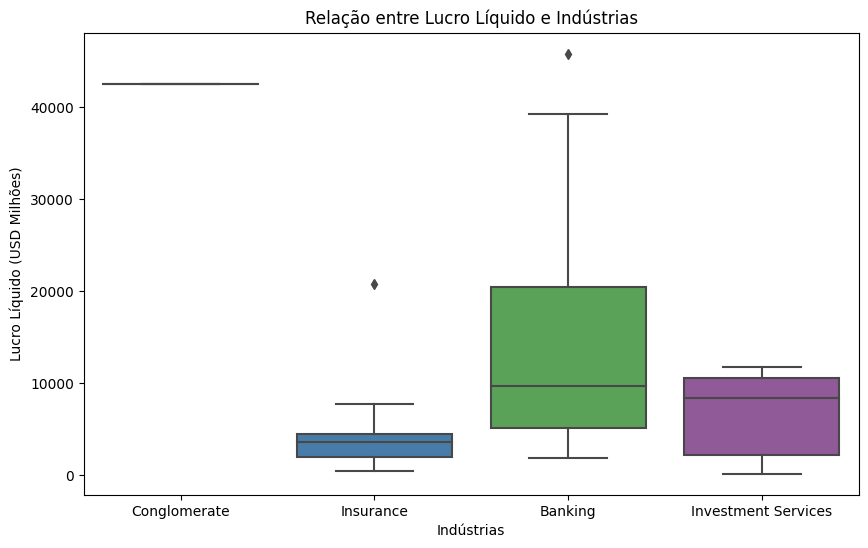

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Industry', y='Net Income in (USD Millions)', data=df, palette='Set1')
plt.title('Relação entre Lucro Líquido e Indústrias')
plt.xlabel('Indústrias')
plt.ylabel('Lucro Líquido (USD Milhões)')
plt.show()

# Análise de rentabilidade

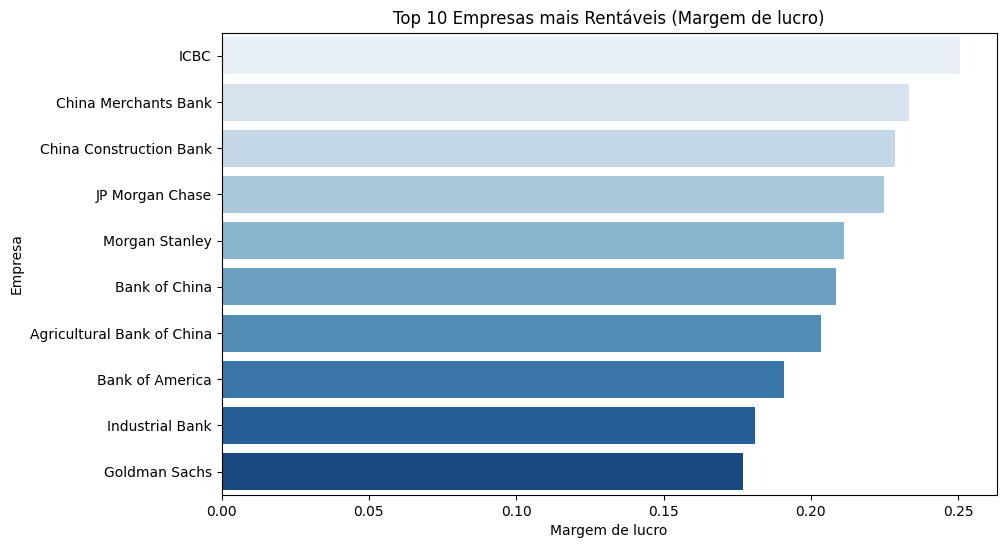

In [11]:
# Estamos definindo uma 'porcentagem' de lucro dividindo o que vai vir pela receita da empresa (ambos na mesma escala)

df['Profit Margin'] = df['Net Income in (USD Millions)'] / df['Revenue in (USD Million)']
top_10_profit = df[['Company', 'Profit Margin']].nlargest(10, 'Profit Margin')

plt.figure(figsize=(10, 6))
sns.barplot(x='Profit Margin', y='Company', data=top_10_profit, palette='Blues')
plt.title('Top 10 Empresas mais Rentáveis (Margem de lucro)')
plt.xlabel('Margem de lucro')
plt.ylabel('Empresa')
plt.show()

In [12]:
profit_margin_by_industry = df.groupby('Industry')['Profit Margin'].mean()
print(profit_margin_by_industry)

Industry
Banking                0.148230
Conglomerate           0.173195
Insurance              0.047259
Investment Services    0.103312
Name: Profit Margin, dtype: float64


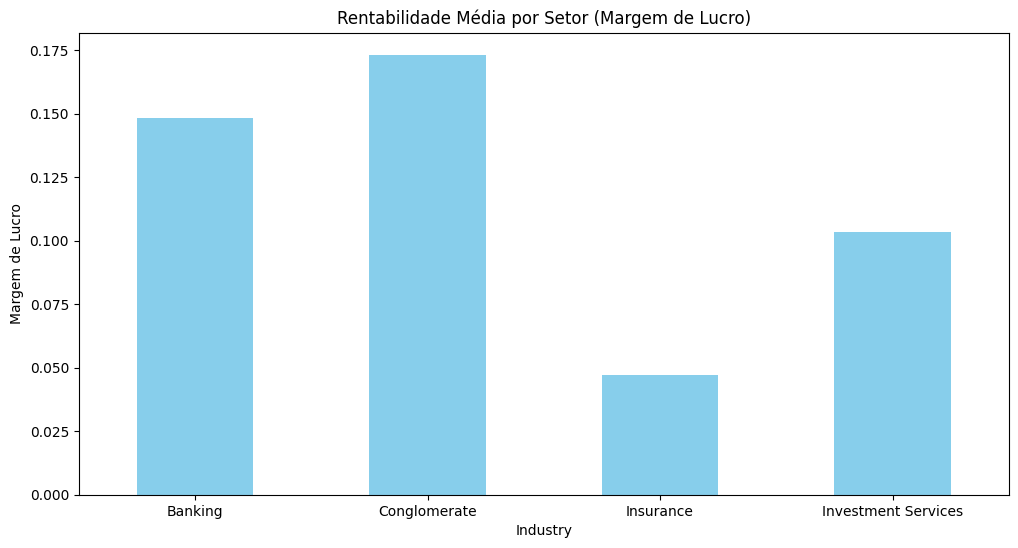

In [13]:
# Gráfico de barras para comparar a rentabilidade entre setores
profit_margin_by_industry.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Rentabilidade Média por Setor (Margem de Lucro)')
plt.ylabel('Margem de Lucro')
plt.xticks(rotation=0)
plt.show()
